In [4]:
import pandas as pd

df = pd.read_csv("US_Superstore.csv", encoding='latin-1')

print(df.head())
print(df.info())
print(df.describe())

df.dropna(subset=['Sales', 'Profit', 'Discount', 'Order Date'], inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

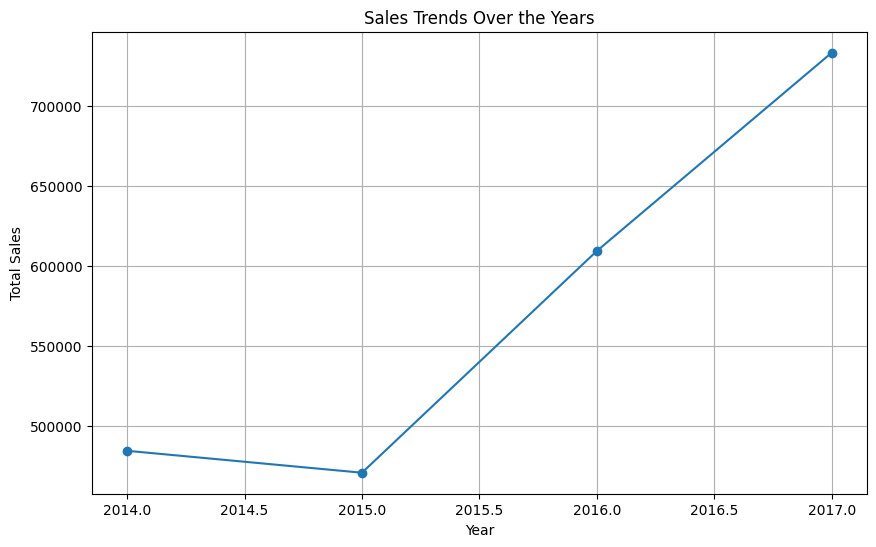

In [5]:
import matplotlib.pyplot as plt

# Aggregate sales by year
df['Year'] = df['Order Date'].dt.year
sales_by_year = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10,6))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')
plt.title("Sales Trends Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


 Interactive Map: Sales by Country

In [6]:
import plotly.express as px
sales_by_country = df.groupby('Country')['Sales'].sum().reset_index()
fig = px.choropleth(sales_by_country,
                    locations='Country',
                    locationmode='country names',
                    color='Sales',
                    color_continuous_scale='Viridis',
                    title='Sales Distribution by Country')
fig.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_13752\2279898885.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(sales_by_country,


 Top 10 Products by Sales

C:\Users\PC\AppData\Local\Temp\ipykernel_13752\2048124572.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




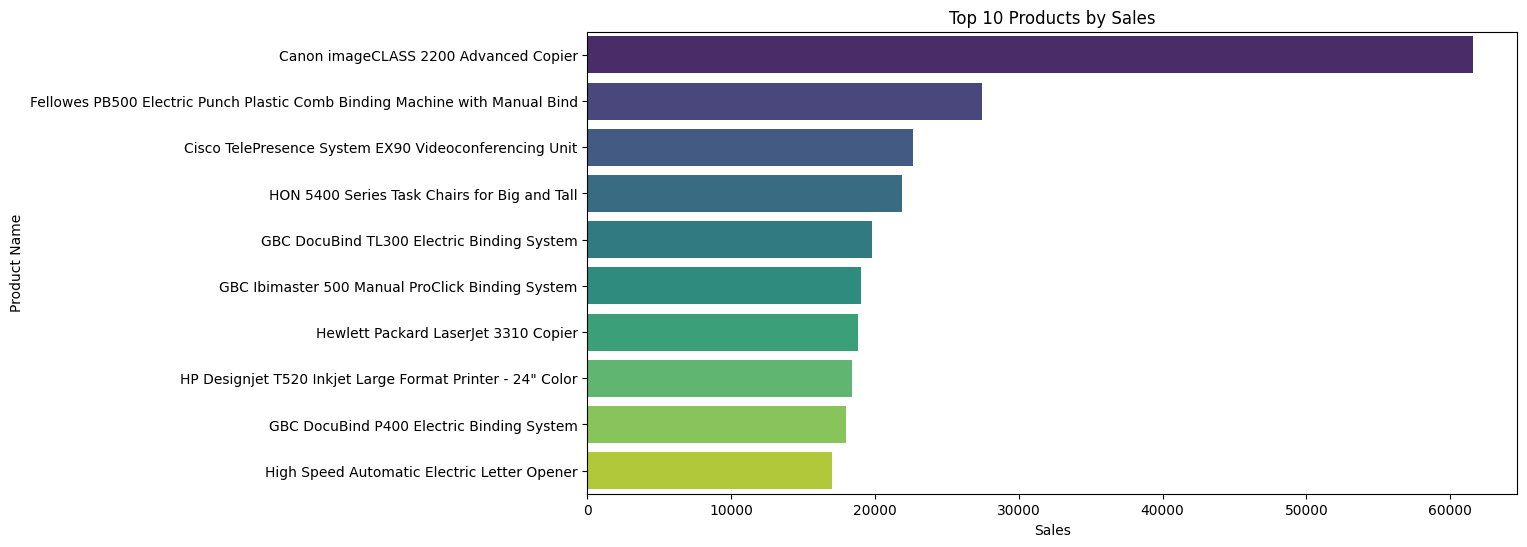

In [7]:
import seaborn as sns

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_products, x='Sales', y='Product Name', palette='viridis')
plt.title("Top 10 Products by Sales")
plt.show()


 Relationship Between Profit and Discount

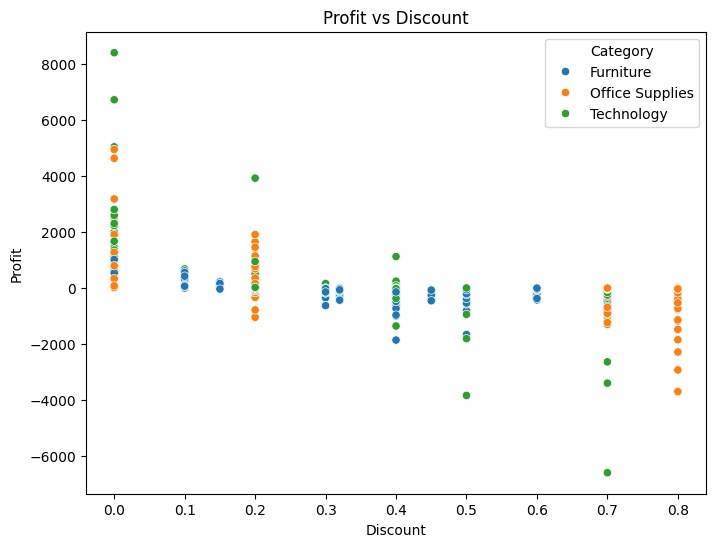

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title("Profit vs Discount")
plt.show()
